In [20]:
import numpy as np
import math
import networkx as nx
import matplotlib.pyplot as plt 
from itertools import combinations
import pandas as pd

In [21]:
# Load data
historical_data = pd.read_csv("files/all_except_last_orders.csv")
last_orders_data = pd.read_csv("files/last_orders_subset.csv")

print(f"Historical data: {len(historical_data)} rows, {historical_data['Member'].nunique()} members")
print(f"Last orders: {len(last_orders_data)} rows, {last_orders_data['Member'].nunique()} members")

Historical data: 28984 rows, 638 members
Last orders: 5487 rows, 638 members


## Test and Validation Set Creation

In [22]:
def create_robust_test_set(historical_data, min_test_items=5, min_context_items=2):
    """
    Create a robust test set ensuring each member has enough items for validation.
    Uses SKUs.
    
    Args:
        historical_data: DataFrame with columns [Member, Order, SKU]
        min_test_items: Minimum number of items needed for validation (default: 5)
        min_context_items: Minimum number of items needed for context/input (default: 2)
        
    Returns:
        training_data: Historical data excluding test orders
        test_members_info: Dict with member -> {
            'test_order': order_id,
            'context_items': list of SKUs for prediction input,
            'validation_items': list of SKUs for evaluation,
            'all_items': all SKUs in test order
        }
    """
    test_members_info = {}
    test_orders_to_exclude = []
    
    min_total_items = min_test_items + min_context_items
    
    for member in historical_data['Member'].unique():
        member_data = historical_data[historical_data['Member'] == member]
        member_orders = member_data.groupby('Order')['SKU'].apply(list).to_dict()
        
        # Find orders with enough items
        suitable_orders = {order: skus for order, skus in member_orders.items() 
                          if len(skus) >= min_total_items}
        
        if suitable_orders:
            # Pick the order with most items
            best_order = max(suitable_orders.items(), key=lambda x: len(x[1]))
            order_id, all_skus = best_order
            
            # Split: context and validation
            context_size = len(all_skus) - min_test_items
            context_items = all_skus[:context_size]
            validation_items = all_skus[context_size:]
            
            test_members_info[member] = {
                'test_order': order_id,
                'context_items': context_items,
                'validation_items': validation_items,
                'all_items': all_skus
            }
            test_orders_to_exclude.append((member, order_id))
        else:
            # Use largest order available
            best_order = max(member_orders.items(), key=lambda x: len(x[1]))
            order_id, all_skus = best_order
            
            if len(all_skus) >= min_context_items + 1:
                validation_size = max(1, len(all_skus) - min_context_items)
                context_items = all_skus[:len(all_skus) - validation_size]
                validation_items = all_skus[len(all_skus) - validation_size:]
                
                test_members_info[member] = {
                    'test_order': order_id,
                    'context_items': context_items,
                    'validation_items': validation_items,
                    'all_items': all_skus
                }
                test_orders_to_exclude.append((member, order_id))
    
    # Create training data by excluding test orders
    training_data = historical_data.copy()
    for member, order_id in test_orders_to_exclude:
        training_data = training_data[~((training_data['Member'] == member) & 
                                       (training_data['Order'] == order_id))]
    
    return training_data, test_members_info


# Create test set
training_data, test_members_info = create_robust_test_set(historical_data, min_test_items=5, min_context_items=2)

print(f"Training set size: {len(training_data)} rows")
print(f"Test set: {len(test_members_info)} members")
print(f"\nTest set statistics:")
print(f"  Members with exactly 5 validation items: {sum(1 for m in test_members_info.values() if len(m['validation_items']) == 5)}")
print(f"  Members with < 5 validation items: {sum(1 for m in test_members_info.values() if len(m['validation_items']) < 5)}")
print(f"  Average context items: {np.mean([len(m['context_items']) for m in test_members_info.values()]):.2f}")
print(f"  Average validation items: {np.mean([len(m['validation_items']) for m in test_members_info.values()]):.2f}")

Training set size: 20791 rows
Test set: 638 members

Test set statistics:
  Members with exactly 5 validation items: 638
  Members with < 5 validation items: 0
  Average context items: 7.84
  Average validation items: 5.00


## Graph Building (Using SKUs)

In [36]:
def build_user_graph_with_skus(member, data):
    """
    Build a co-occurrence graph using product SKUs.
    
    Args:
        member: User ID to build graph for
        data: DataFrame with columns [Member, Order, SKU]
        
    Returns:
        NetworkX graph with SKUs as nodes and order-level co-occurrence as edges
    """
    user_graph = nx.Graph()
    
    # Get all orders for this member
    member_data = data[data['Member'] == member]
    
    # Build graph from each order separately
    for order_id in member_data['Order'].unique():
        order_skus = member_data[member_data['Order'] == order_id]['SKU'].tolist()
        
        # Add co-occurrence edges within this specific order
        for sku1, sku2 in combinations(order_skus, 2):
            if user_graph.has_edge(sku1, sku2):
                user_graph[sku1][sku2]['weight'] += 1
            else:
                user_graph.add_edge(sku1, sku2, weight=1)
    
    return user_graph


def build_user_graphs_from_data(data):
    """
    Build user-specific graphs from training data using order-level co-occurrence.
    Uses product SKUs.
    
    Args:
        data: DataFrame with columns [Member, Order, SKU]
        
    Returns:
        Dict mapping Member -> NetworkX Graph
    """
    user_graphs = {}
    for member in data['Member'].unique():
        user_graphs[member] = build_user_graph_with_skus(member, data)
    
    return user_graphs


def build_global_graph_from_data(data):
    """
    Build global all-product graph from training data using order-level co-occurrence.
    Uses product SKUs.
    
    Args:
        data: DataFrame with columns [Order, SKU]
        
    Returns:
        NetworkX Graph
    """
    global_graph = nx.Graph()
    for order_id in data['Order'].unique():
        order_skus = data[data['Order'] == order_id]['SKU'].tolist()
        for sku1, sku2 in combinations(order_skus, 2):
            if global_graph.has_edge(sku1, sku2):
                global_graph[sku1][sku2]['weight'] += 1
            else:
                global_graph.add_edge(sku1, sku2, weight=1)
    
    return global_graph


# Build graphs from training data
user_graphs_train = build_user_graphs_from_data(training_data)
global_graph_train = build_global_graph_from_data(training_data)

print(f"User-specific graphs: {len(user_graphs_train)} members")
print(f"Global graph: {global_graph_train.number_of_nodes()} nodes, {global_graph_train.number_of_edges()} edges")

User-specific graphs: 521 members
Global graph: 626 nodes, 37462 edges


In [40]:
# Keep edges with weight >= 2 to reduce noise
for member, graph in user_graphs_train.items():
    edges_to_remove = [(u, v) for u, v, d in graph.edges(data=True) if d['weight'] < 2]
    graph.remove_edges_from(edges_to_remove)
# Keep edges with weight >= 2 to reduce noise
edges_to_remove_global = [(u, v) for u, v, d in global_graph_train.edges(data=True) if d['weight'] <= 2]
global_graph_train.remove_edges_from(edges_to_remove_global)
print("Filtered graphs to remove low-weight edges.")

Filtered graphs to remove low-weight edges.


## Visualize Sample Graph

Sample member: SSCEHNS
Graph nodes: 44
Graph edges: 68


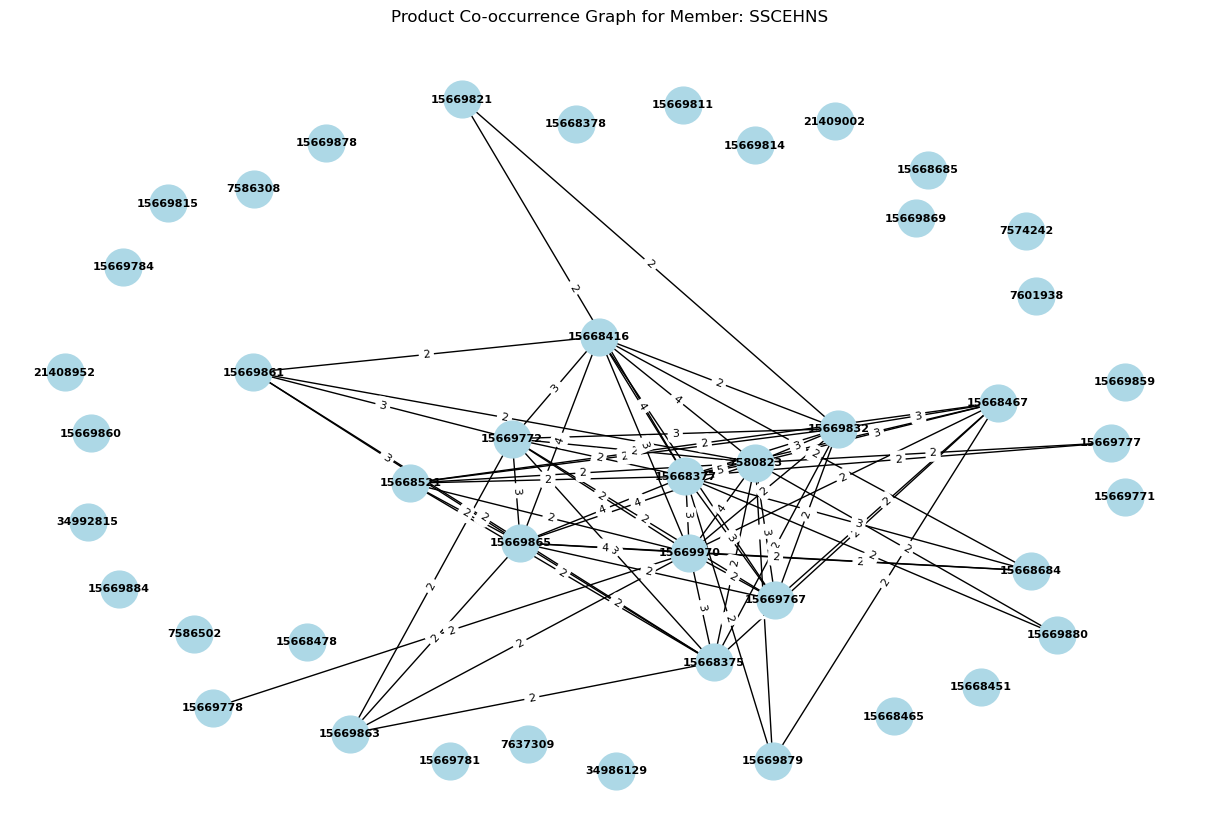

In [38]:
# Visualize a sample user's graph
sample_member = list(user_graphs_train.keys())[0]
sample_graph = user_graphs_train[sample_member]

print(f"Sample member: {sample_member}")
print(f"Graph nodes: {sample_graph.number_of_nodes()}")
print(f"Graph edges: {sample_graph.number_of_edges()}")

if sample_graph.number_of_nodes() > 0 and sample_graph.number_of_nodes() < 50:
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(sample_graph, k=2, iterations=50)
    nx.draw(sample_graph, pos, with_labels=True, node_size=700, 
            node_color="lightblue", font_size=8, font_weight='bold')
    edge_labels = nx.get_edge_attributes(sample_graph, 'weight')
    nx.draw_networkx_edge_labels(sample_graph, pos, edge_labels=edge_labels, font_size=8)
    plt.title(f"Product Co-occurrence Graph for Member: {sample_member}")
    plt.show()
else:
    print(f"Graph too large to visualize ({sample_graph.number_of_nodes()} nodes)")

In [32]:
# Sample test member info
sample_test_member = list(test_members_info.keys())[0]
sample_info = test_members_info[sample_test_member]
last_orders_data[last_orders_data['Member'] == sample_test_member]

,Order,SKU,Member,Delivery Date,Name
662,8069966,21408952,SSCEHNS,30/03/14,Whole Spices
1230,8069966,15669863,SSCEHNS,30/03/14,Moong Dal
1844,8069966,15669970,SSCEHNS,30/03/14,Cashews
4528,8069966,15669865,SSCEHNS,30/03/14,Other Dals
4869,8069966,15668684,SSCEHNS,30/03/14,Beans
5108,8069966,15668521,SSCEHNS,30/03/14,Bread
5440,8069966,15669818,SSCEHNS,30/03/14,Whole Spices


## Explore Graph Properties

In [26]:
# Sample test member info
sample_test_member = list(test_members_info.keys())[0]
sample_info = test_members_info[sample_test_member]

print(f"Sample Test Member: {sample_test_member}")
print(f"  Context items ({len(sample_info['context_items'])}): {sample_info['context_items']}")
print(f"  Validation items ({len(sample_info['validation_items'])}): {sample_info['validation_items']}")

Sample Test Member: SSCEHNS
  Context items (6): [15668375, 15668478, 15668467, 15669861, 15669863, 15669778]
  Validation items (5): [15669878, 15669767, 15669772, 15669865, 7580802]


In [29]:
test_members_info

{'SSCEHNS': {'test_order': 8382662,
  'context_items': [15668375,
   15668478,
   15668467,
   15669861,
   15669863,
   15669778],
  'validation_items': [15669878, 15669767, 15669772, 15669865, 7580802],
  'all_items': [15668375,
   15668478,
   15668467,
   15669861,
   15669863,
   15669778,
   15669878,
   15669767,
   15669772,
   15669865,
   7580802]},
 'SSCESNS': {'test_order': 8202195,
  'context_items': [15668465,
   15668378,
   15668453,
   15668377,
   15669821,
   15669760,
   15669857,
   15669869,
   15669832,
   15668462,
   15669777,
   15669770,
   15669874,
   15669838],
  'validation_items': [15669799, 15670267, 34986129, 21408953, 29247044],
  'all_items': [15668465,
   15668378,
   15668453,
   15668377,
   15669821,
   15669760,
   15669857,
   15669869,
   15669832,
   15668462,
   15669777,
   15669770,
   15669874,
   15669838,
   15669799,
   15670267,
   34986129,
   21408953,
   29247044]},
 'SSCEWZO': {'test_order': 8228254,
  'context_items': [15668379, 

In [42]:

historical_data.pivot_table

,Order,SKU,Member,Delivery Date,Name
0,8358896,15668375,SSCEHNS,02/11/13,Root Vegetables
1,8358896,15668467,SSCEHNS,02/11/13,Beans
2,8358896,15669863,SSCEHNS,02/11/13,Moong Dal
3,8358896,15669778,SSCEHNS,02/11/13,Other Dals
4,8358896,15669767,SSCEHNS,02/11/13,Urad Dal
...,...,...,...,...,...
28979,7466404,15669886,SWRNHCS,01/09/13,Sooji & Rava
28980,7466404,15669874,SWRNHCS,01/09/13,Avalakki / Poha
28981,7466404,15670260,SWRNHCS,01/09/13,Organic F&V
28982,7466404,15670196,SWRNHCS,01/09/13,Organic F&V


In [49]:
from sortedcontainers import SortedList
grouped_last = last_orders_data.groupby('Member')['SKU'].apply(SortedList)

# Sort again by SortedList to ensure order  
grouped_last = grouped_last.sort_values()

# Print first 5 complete rows to verify
for member, skus in grouped_last.head(5).items():
    print(f"Member: {member}, SKUs: {list(skus)}")



Member: SWCRWEH, SKUs: [6884195, 7571385, 7594821, 7625556, 7637309, 15668381, 15668462, 15668465, 15668468, 92436884]
Member: SWERWCW, SKUs: [6884195, 7627858, 7642814, 15668377, 15668381, 15668448, 15668460, 15668466, 15668477, 15668495, 15669780, 15669817, 92436884]
Member: SWOCEOZ, SKUs: [6884195, 7689511, 15669780, 15669823, 15669829, 34992815]
Member: SSWNRHC, SKUs: [7541573, 7569624, 15669765, 15669819, 15669860, 15669861, 15669869, 15669875]
Member: SSLZROW, SKUs: [7541573, 7572240, 7579697, 15668377, 15668378, 15668381, 15668467, 15668520, 15669910, 93091858]


In [53]:
historical_data['quantity'] = 1
hist_pivot = historical_data.pivot(index="SKU", columns='Order', values='quantity').reset_index()
hist_pivot.fillna(0, inplace=True)
hist_pivot

Order,SKU,7340037,7340368,7340638,7340671,7340893,7341000,7341085,7341350,7341392,...,8383509,8384397,8384428,8385119,8385848,8385942,8386131,8386872,8387583,8387603
0,6884195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7541573,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7543241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7547271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7547296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,93176430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
628,93176431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
629,93289485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
630,93289486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
from sklearn.metrics import pairwise_distances

# The issue is that 'SKU' column is included in the calculation.
# We need to set it as index so only the order data is used for similarity.
matrix_data = hist_pivot.set_index('SKU')

# Calculate cosine similarity
# Note: pairwise_distances returns distance (0=identical, 1=orthogonal for cosine)
# So similarity = 1 - distance
sku_sim = 1 - pairwise_distances(matrix_data.values, metric='correlation')

# Create a DataFrame with SKUs as index and columns
sku_sim_df = pd.DataFrame(sku_sim, index=matrix_data.index, columns=matrix_data.index)

print("Pairwise SKU Similarity Matrix Shape:", sku_sim_df.shape)
sku_sim_df.iloc[:5, :5]

Pairwise SKU Similarity Matrix Shape: (632, 632)


SKU,6884195,7541573,7543241,7547271,7547296
SKU,,,,,
6884195,1.000000,-0.005992,-0.003068,-0.005232,-0.003235
7541573,-0.005992,1.000000,-0.006797,-0.011591,0.047530
7543241,-0.003068,-0.006797,1.000000,-0.005935,-0.003669
7547271,-0.005232,-0.011591,-0.005935,1.000000,0.181095
7547296,-0.003235,0.047530,-0.003669,0.181095,1.000000


In [112]:
from collections import defaultdict
items = test_members_info['SSCLLWS']['context_items']
all_similar = defaultdict(list)
for item in items:
    if item in sku_sim_df.index:
        similar_items = sku_sim_df[item].sort_values(ascending=False).head(10)
        for sim_item, score in similar_items.items():
            all_similar[sim_item].append(score)
    else:
        print(f"SKU {item} not found in similarity matrix.\n")
        
weighted_scores = {}
for sim_item, scores in all_similar.items():
    if(sim_item not in items):  # Exclude already owned items   
        weighted_scores[sim_item] = sum(scores) 
# Sort by weighted score
ranked_items = sorted(weighted_scores.items(), key=lambda x: x[1], reverse=True)
print(ranked_items[:5])
test_members_info['SSCLLWS']

# Print name of all items from historical data table instead of just SKU in each line
sku_name_dict = historical_data.set_index('SKU')['Name'].to_dict()
for sku, score in ranked_items[:5]:
    name = sku_name_dict.get(sku, "Unknown Product")
    print(f"SKU: {sku}, Name: {name}, Score: {score}")

# print every item with name in items list of memeber
items = test_members_info['SSCLLWS']['context_items']
for item in items:
    name = sku_name_dict.get(item, "Unknown Product")
    print(f"SKU: {item}, Name: {name}")

print("X"*10)
expected_items = test_members_info['SSCLLWS']['validation_items']
for item in expected_items:
    name = sku_name_dict.get(item, "Unknown Product")
    print(f"SKU: {item}, Name: {name}")

[(15670250, 0.7164008491943629), (15670163, 0.6137840681516161), (15670241, 0.4182912052382812), (15670252, 0.41319911651716623), (15670246, 0.39899381586135263)]
SKU: 15670250, Name: Organic F&V, Score: 0.7164008491943629
SKU: 15670163, Name: Organic F&V, Score: 0.6137840681516161
SKU: 15670241, Name: Organic F&V, Score: 0.4182912052382812
SKU: 15670252, Name: Organic F&V, Score: 0.41319911651716623
SKU: 15670246, Name: Organic F&V, Score: 0.39899381586135263
SKU: 15668375, Name: Root Vegetables
SKU: 15668451, Name: Brinjals
SKU: 15670260, Name: Organic F&V
SKU: 15670157, Name: Organic F&V
SKU: 15670251, Name: Organic F&V
XXXXXXXXXX
SKU: 15670246, Name: Organic F&V
SKU: 15670196, Name: Organic F&V
SKU: 29247172, Name: Whole Spices
SKU: 21409181, Name: Brinjals
SKU: 34992815, Name: Cookies


In [82]:
group_name = historical_data.groupby('Name')['SKU'].apply(list).reset_index()
for name, skus in group_name.head(5).values:
    print(f"Name: {name}, Total: {len(skus)}, SKUs: {skus}")

Name: Agarbatti, Total: 70, SKUs: [92380875, 7598720, 7598777, 7598777, 7598777, 7598777, 7598720, 7598777, 92380875, 7598720, 7598720, 7598720, 7598720, 7598720, 7598720, 7598720, 92380875, 92380875, 7598720, 7598777, 92380875, 7598777, 92380875, 7598720, 92380875, 7598720, 92380875, 7598777, 92380875, 92380875, 92380927, 92380927, 7598720, 92380875, 92380875, 92380875, 7598777, 7598777, 7598777, 7598777, 7598777, 7598777, 92380927, 7598777, 7598777, 7598777, 7598777, 92380875, 92380927, 7598777, 7598720, 92380875, 7598777, 92380875, 7598777, 7598777, 92380875, 92380875, 92380927, 7598777, 7598777, 92380927, 7598777, 7598777, 7598720, 7598720, 7598720, 7598720, 92380875, 92380875]
Name: Almonds, Total: 222, SKUs: [15669811, 15669810, 15669810, 15669810, 15669811, 15669810, 15669810, 15669811, 15669811, 15669976, 15670010, 15670010, 15669976, 15669811, 15669977, 15669977, 15670010, 15669976, 15669976, 15669976, 15669976, 15670009, 15669811, 15670010, 15669976, 15669810, 15670009, 15670

In [111]:
random_20_users = np.random.choice(historical_data['Member'].unique(), size=20, replace=False)
print("Random 20 users:", random_20_users)
dict_name = historical_data.set_index('SKU')['Name'].to_dict()
users = random_20_users

for user in users:
    print("Data for user:", user    )
    data_for_user = historical_data[historical_data['Member'] == user]
    # add date in basket printing
    group_data = data_for_user.groupby('Order')['SKU'].apply(list).reset_index()
    for order_id, skus in group_data.values:
        names = sorted([dict_name[sku],sku] for sku in skus)
        print(f"Names: {names}")

Random 20 users: ['SWHCZWL' 'SWOHOZR' 'SSWNZEC' 'SWHSWOW' 'SSZWOZH' 'SWLOHSW' 'SSCLLWS'
 'SSZLEOL' 'SSLWWWH' 'SWNZWNZ' 'SWOSCER' 'SWEOLLO' 'SSEHHWW' 'SWNHHRL'
 'SSSHLHL' 'SSWRLOE' 'SSCRHLH' 'SWHERHH' 'SWHRCNL' 'SSZZZOE']
Data for user: SWHCZWL
Names: [['Brinjals', 15668457], ['Namkeen', 7653522], ['Other Dals', 15669996], ['Other Insect Repellent', 7743303], ['Phenyles & Acids', 93289485], ['Raw Peanuts', 15669861], ['Raw Rice', 15669782], ['Whole Spices', 15669760]]
Names: [['Avalakki / Poha', 15669874], ['Basmati Rice', 15669784], ['Besan', 15669764], ['Cashews', 15669806], ['Moong Dal', 15669863], ['Moong Dal', 15669885], ['Namkeen', 7653522], ['Namkeen', 93176430], ['Namkeen', 93176431], ['Other Dals', 15669763], ['Other Dals', 15669769], ['Other Dals', 15669778], ['Other Dals', 15669819], ['Phenyles & Acids', 93289487], ['Raw Rice', 15669782], ['Sooji & Rava', 15669881], ['Sugar', 15669856], ['Toor Dal', 15670267]]
Names: [['Almonds', 15669810], ['Avalakki / Poha', 15669786], ['Ha

In [109]:
group_name = historical_data.groupby('Name')['SKU'].apply(list).reset_index()
for name, skus in group_name.head(5).values:
    print(f"Name: {name}, Total: {len(skus)}, SKUs: {skus}")
# Identify sku present in multiple names
sku_name_counts = historical_data.groupby('SKU')['Name'].apply(list).reset_index()
for sku, names in sku_name_counts.head(10).values:
    print(f"SKU: {sku}, Names: {names}")

Name: Agarbatti, Total: 70, SKUs: [92380875, 7598720, 7598777, 7598777, 7598777, 7598777, 7598720, 7598777, 92380875, 7598720, 7598720, 7598720, 7598720, 7598720, 7598720, 7598720, 92380875, 92380875, 7598720, 7598777, 92380875, 7598777, 92380875, 7598720, 92380875, 7598720, 92380875, 7598777, 92380875, 92380875, 92380927, 92380927, 7598720, 92380875, 92380875, 92380875, 7598777, 7598777, 7598777, 7598777, 7598777, 7598777, 92380927, 7598777, 7598777, 7598777, 7598777, 92380875, 92380927, 7598777, 7598720, 92380875, 7598777, 92380875, 7598777, 7598777, 92380875, 92380875, 92380927, 7598777, 7598777, 92380927, 7598777, 7598777, 7598720, 7598720, 7598720, 7598720, 92380875, 92380875]
Name: Almonds, Total: 222, SKUs: [15669811, 15669810, 15669810, 15669810, 15669811, 15669810, 15669810, 15669811, 15669811, 15669976, 15670010, 15670010, 15669976, 15669811, 15669977, 15669977, 15670010, 15669976, 15669976, 15669976, 15669976, 15670009, 15669811, 15670010, 15669976, 15669810, 15670009, 15670

In [114]:
pivot_by_orders = historical_data.pivot(index='Order', columns='SKU', values='quantity').reset_index()
pivot_by_orders.fillna(0)

SKU,Order,6884195,7541573,7543241,7547271,7547296,7547323,7548497,7548498,7548511,...,93141092,93141093,93156751,93174226,93176429,93176430,93176431,93289485,93289486,93289487
0,7340037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7340368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7340638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7340671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7340893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2590,8385942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2591,8386131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2592,8386872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2593,8387583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
len(historical_data.SKU.unique())

632

In [137]:
from collections import defaultdict
from sklearn.metrics import pairwise_distances

# Ensure we have the pivot table with 0s (handling NaN from pivot)
pivot_filled = pivot_by_orders.fillna(0)

# 1. Prepare the input basket vector
items = test_members_info['SSCLLWS']['context_items']
feature_columns = pivot_filled.columns.drop('Order')

# Create a zero vector for the basket aligned with pivot columns
basket_vector = pd.DataFrame(0, index=[0], columns=feature_columns)

for item in items:
    if item in basket_vector.columns:
        basket_vector.at[0, item] = 1
    else:
        print(f"Item {item} not found in pivot columns.")

# 2. Calculate similarity
# Extract feature matrix (orders x items)
historical_matrix = pivot_filled[feature_columns].values
basket_arr = basket_vector.values

# Calculate Cosine Similarity (1 - Cosine Distance)
# Result is shape (1, n_orders)
similarities = 1 - pairwise_distances(basket_arr, historical_matrix, metric='cosine')

# 3. Get Top 10 Neighbors with User Boost
# Map similarities to Order IDs and get member info
current_member = 'SSCLLWS'  # The user we're recommending for

# Create a mapping of order_id -> member for faster lookup
order_to_member = historical_data.groupby('Order')['Member'].first()

# Apply boost BEFORE selecting top 10
boosted_scores = {}
for order_id, base_score in zip(pivot_filled['Order'], similarities[0]):
    order_member = order_to_member.get(order_id)
    
    if order_member == current_member:
        # Boost score by 300% for same-user orders to ensure they rank higher
        boosted_score = base_score * 4.0
    else:
        boosted_score = base_score
    
    boosted_scores[order_id] = boosted_score

# Convert to Series and get top 10
boosted_series = pd.Series(boosted_scores)
top_10_orders = boosted_series.sort_values(ascending=False).head(10)

# Count same-user orders in top 10
same_user_count = sum(1 for oid in top_10_orders.index if order_to_member.get(oid) == current_member)
print(f"Same-user orders in top 10: {same_user_count}/10")

print("Top 10 Similar Orders (Order ID -> Similarity, with Same-User Boost):")
print(top_10_orders)

# Print all 10 orders with names and member info
for order_id, score in top_10_orders.items():
    order_member = historical_data[historical_data['Order'] == order_id]['Member'].iloc[0]
    order_items = historical_data[historical_data['Order'] == order_id]['SKU'].unique()
    item_names = [sku_name_dict.get(sku, "Unknown Product") for sku in order_items]
    same_user_flag = "⭐ SAME USER" if order_member == current_member else ""
    print(f"Order ID: {order_id}, Member: {order_member}, Similarity: {score:.4f} {same_user_flag}")
    print(f"  Items: {item_names[:5]}...")  # Show first 5 items
# 4. Recommend Next 5 Items - Hybrid Approach
# Combines Order Similarity + Item-Item Similarity
candidate_scores = defaultdict(float)

# Step 4a: Get candidate items from similar orders
for order_id, order_sim_score in top_10_orders.items():
    order_items = historical_data[historical_data['Order'] == order_id]['SKU'].unique()
    
    for sku in order_items:
        if sku not in items:
            # Step 4b: Calculate item-item similarity between candidate and basket items
            item_similarities = []
            
            for basket_item in items:
                # Check if both items exist in the item-item similarity matrix
                if sku in sku_sim_df.index and basket_item in sku_sim_df.columns:
                    item_sim = sku_sim_df.loc[sku, basket_item]
                    item_similarities.append(item_sim)
            
            # Combine scores: order similarity * average item-item similarity
            if item_similarities:
                avg_item_sim = np.mean(item_similarities)
                # Hybrid score: weighted combination
                hybrid_score = (0.4 * order_sim_score) + (0.6 * avg_item_sim)
                candidate_scores[sku] += hybrid_score
            else:
                # Fallback: use only order similarity if item not in similarity matrix
                candidate_scores[sku] += order_sim_score * 0.5

print(f"\nFound {len(candidate_scores)} candidate items")
print("Sample scores:", dict(list(candidate_scores.items())[:3]))

# Sort by score
top_10_recs = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)[:10]

# Display results with names
print("\nTop 10 Recommended Next Items (Hybrid: Order + Item Similarity):")
sku_name_dict = historical_data.set_index('SKU')['Name'].to_dict()

for sku, score in top_10_recs:
    name = sku_name_dict.get(sku, "Unknown Product")
    print(f"SKU: {sku}, Name: {name}, Score: {score:.4f}")  

Same-user orders in top 10: 4/10
Top 10 Similar Orders (Order ID -> Similarity, with Same-User Boost):
8263980    2.828427
8326548    1.697056
8291178    0.632456
8238365    0.596285
7346599    0.565685
8339457    0.565685
8345672    0.474342
7419744    0.474342
7762069    0.474342
8185088    0.474342
dtype: float64
Order ID: 8263980, Member: SSCLLWS, Similarity: 2.8284 ⭐ SAME USER
  Items: ['Root Vegetables', 'Brinjals', 'Organic F&V', 'Organic F&V', 'Organic F&V']...
Order ID: 8326548, Member: SSCLLWS, Similarity: 1.6971 ⭐ SAME USER
  Items: ['Root Vegetables', 'Brinjals', 'Beans', 'Beans', 'Organic Flours']...
Order ID: 8291178, Member: SSCLLWS, Similarity: 0.6325 ⭐ SAME USER
  Items: ['Root Vegetables', 'Toor Dal', 'Organic F&V', 'Organic F&V', 'Organic F&V']...
Order ID: 8238365, Member: SWLNCNW, Similarity: 0.5963 
  Items: ['Root Vegetables', 'Root Vegetables', 'Beans', 'Beans', 'Organic F&V']...
Order ID: 7346599, Member: SSLOLSS, Similarity: 0.5657 
  Items: ['Other Vegetables

In [133]:
for i in [15670246, 15670196, 29247172, 21409181, 34992815]:
    name = sku_name_dict.get(i, "Unknown Product")
    print(f"SKU: {i}, Name: {name}")

SKU: 15670246, Name: Organic F&V
SKU: 15670196, Name: Organic F&V
SKU: 29247172, Name: Whole Spices
SKU: 21409181, Name: Brinjals
SKU: 34992815, Name: Cookies


In [ ]:
order_ids_from_SSCLLWS = historical_data[historical_data['Member'] == 'SSCLLWS']['Order'].unique()
order_ids_from_SSCLLWS



array([8326548, 8339457, 8291178, 8263980])

Data for user: SSCLLWS
Names: [['Brinjals', 15668451], ['Brinjals', 21409181], ['Cookies', 34992815], ['Organic F&V', 15670157], ['Organic F&V', 15670196], ['Organic F&V', 15670246], ['Organic F&V', 15670251], ['Organic F&V', 15670260], ['Root Vegetables', 15668375], ['Whole Spices', 29247172]]

Names: [['Organic F&V', 15670158], ['Organic F&V', 15670246], ['Organic F&V', 15670250], ['Organic F&V', 15670251], ['Organic F&V', 15670253], ['Organic F&V', 15670254], ['Root Vegetables', 15668466], ['Toor Dal', 15669859]]

Names: [['Beans', 15668469], ['Beans', 15668470], ['Brinjals', 15668451], ['Brinjals', 15668455], ['Organic F&V', 15670207], ['Organic F&V', 15670241], ['Organic F&V', 15670251], ['Organic F&V', 15670260], ['Organic Flours', 7587698], ['Root Vegetables', 15668465]]

Names: [['Beans', 15668467], ['Organic F&V', 15670171], ['Organic F&V', 15670207], ['Organic F&V', 15670246], ['Organic F&V', 15670252], ['Organic F&V', 15670260], ['Root Vegetables', 15668377], ['Root Vegetables', 15668465], ['Urad Dal', 15669773], ['Whole Spices', 34986123]]
Data for user: SSZLEOL

In [129]:
test_members_info['SSCLLWS']

{'test_order': 8263980,
 'context_items': [15668375, 15668451, 15670260, 15670157, 15670251],
 'validation_items': [15670246, 15670196, 29247172, 21409181, 34992815],
 'all_items': [15668375,
  15668451,
  15670260,
  15670157,
  15670251,
  15670246,
  15670196,
  29247172,
  21409181,
  34992815]}

## Evaluate on Test Set - Calculate Recall@5

In [148]:
def predict_top_k_items(member, context_items, k=5, user_boost=6.0, order_weight=0.7, item_weight=0.3, candidate_boost=1.5):
    """
    Predict top K items for a member based on their context items.
    Uses hybrid approach: Order Similarity + Item-Item Similarity with two-level same-user boost.
    
    Args:
        member: Member ID to predict for
        context_items: List of SKU items in the user's basket
        k: Number of items to recommend
        user_boost: Multiplier for same-user orders (order-level boost)
        order_weight: Weight for order similarity in hybrid score
        item_weight: Weight for item-item similarity in hybrid score
        candidate_boost: Multiplier for candidates from same-user orders (item-level boost)
    
    Returns:
        List of top K recommended SKU IDs
    """
    # 1. Create basket vector
    basket_vector = pd.DataFrame(0, index=[0], columns=feature_columns)
    for item in context_items:
        if item in basket_vector.columns:
            basket_vector.at[0, item] = 1
    
    # 2. Calculate order similarities
    basket_arr = basket_vector.values
    similarities = 1 - pairwise_distances(basket_arr, historical_matrix, metric='cosine')
    
    # 3. Apply same-user boost at order level
    boosted_scores = {}
    for order_id, base_score in zip(pivot_filled['Order'], similarities[0]):
        order_member = order_to_member.get(order_id)
        if order_member == member:
            boosted_score = base_score * user_boost
        else:
            boosted_score = base_score
        boosted_scores[order_id] = boosted_score
    
    # Get top 10 similar orders
    boosted_series = pd.Series(boosted_scores)
    top_orders = boosted_series.sort_values(ascending=False).head(10)
    
    # 4. Get candidate items with hybrid scoring + candidate-level same-user boost
    candidate_scores = defaultdict(float)
    
    for order_id, order_sim_score in top_orders.items():
        order_items = historical_data[historical_data['Order'] == order_id]['SKU'].unique()
        order_member = order_to_member.get(order_id)
        
        # Check if this order is from the same user
        same_user = (order_member == member)
        
        for sku in order_items:
            if sku not in context_items:
                # Calculate item-item similarity
                item_similarities = []
                for basket_item in context_items:
                    if sku in sku_sim_df.index and basket_item in sku_sim_df.columns:
                        item_sim = sku_sim_df.loc[sku, basket_item]
                        item_similarities.append(item_sim)
                
                # Hybrid scoring
                if item_similarities:
                    avg_item_sim = np.mean(item_similarities)
                    hybrid_score = (order_weight * order_sim_score) + (item_weight * avg_item_sim)
                    
                    # Apply candidate-level boost for same-user items
                    if same_user:
                        hybrid_score *= candidate_boost
                    
                    candidate_scores[sku] += hybrid_score
                else:
                    base_score = order_sim_score * 0.5
                    # Apply candidate-level boost for same-user items
                    if same_user:
                        base_score *= candidate_boost
                    candidate_scores[sku] += base_score
    
    # 5. Return top K
    top_k = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return [sku for sku, score in top_k]


# Pre-compute shared data for efficiency
feature_columns = pivot_filled.columns.drop('Order')
historical_matrix = pivot_filled[feature_columns].values
order_to_member = historical_data.groupby('Order')['Member'].first()

print("Prediction function ready!")

Prediction function ready!


In [151]:
def calculate_recall_at_k(predictions, actual, k=5):
    """
    Calculate Recall@K.
    
    Args:
        predictions: List of predicted items (top K)
        actual: List of actual items (validation set)
        k: K value for recall calculation
    
    Returns:
        Recall@K score (0 to 1)
    """
    if len(actual) == 0:
        return 0.0
    
    # How many actual items are in the top K predictions?
    hits = len(set(predictions[:k]) & set(actual))
    
    # Recall = hits / total actual items
    recall = hits / len(actual)
    return recall


# Evaluate on all test members
results = []
recall_scores = []

print("Evaluating on test set...")
print("="*80)

for i, (member, info) in enumerate(test_members_info.items()):
    context_items = info['context_items']
    validation_items = info['validation_items']
    
    # Get predictions
    predictions = predict_top_k_items(member, context_items, k=5, user_boost=7.0, order_weight=0.8, item_weight=0.3, candidate_boost=1.8)
    
    # Calculate Recall@5
    recall = calculate_recall_at_k(predictions, validation_items, k=5)
    recall_scores.append(recall)
    
    results.append({
        'member': member,
        'context_size': len(context_items),
        'validation_size': len(validation_items),
        'predictions': predictions,
        'actual': validation_items,
        'recall@5': recall,
        'hits': len(set(predictions) & set(validation_items))
    })
    
    # Print progress every 50 members
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(test_members_info)} members... Avg Recall@5: {np.mean(recall_scores):.4f}")

print("="*80)
print(f"\n✅ Evaluation Complete!")
print(f"Total members evaluated: {len(test_members_info)}")
print(f"\n📊 Overall Metrics:")
print(f"  Average Recall@5: {np.mean(recall_scores):.4f}")
print(f"  Median Recall@5:  {np.median(recall_scores):.4f}")
print(f"  Min Recall@5:     {np.min(recall_scores):.4f}")
print(f"  Max Recall@5:     {np.max(recall_scores):.4f}")
print(f"  Std Dev:          {np.std(recall_scores):.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df.head(10)

Evaluating on test set...
Processed 50/638 members... Avg Recall@5: 0.9320
Processed 50/638 members... Avg Recall@5: 0.9320
Processed 100/638 members... Avg Recall@5: 0.9380
Processed 100/638 members... Avg Recall@5: 0.9380
Processed 150/638 members... Avg Recall@5: 0.9200
Processed 150/638 members... Avg Recall@5: 0.9200
Processed 200/638 members... Avg Recall@5: 0.9230
Processed 200/638 members... Avg Recall@5: 0.9230
Processed 250/638 members... Avg Recall@5: 0.9144
Processed 250/638 members... Avg Recall@5: 0.9144
Processed 300/638 members... Avg Recall@5: 0.9100
Processed 300/638 members... Avg Recall@5: 0.9100
Processed 350/638 members... Avg Recall@5: 0.9040
Processed 350/638 members... Avg Recall@5: 0.9040
Processed 400/638 members... Avg Recall@5: 0.9035
Processed 400/638 members... Avg Recall@5: 0.9035
Processed 450/638 members... Avg Recall@5: 0.9022
Processed 450/638 members... Avg Recall@5: 0.9022
Processed 500/638 members... Avg Recall@5: 0.8988
Processed 500/638 members.

,member,context_size,validation_size,predictions,actual,recall@5,hits
0,SSCEHNS,6,5,"[15669772, 15669865, 15669767, 15669970, 15669...","[15669878, 15669767, 15669772, 15669865, 7580802]",0.6,3
1,SSCESNS,14,5,"[15670267, 29247044, 15669799, 21408953, 34986...","[15669799, 15670267, 34986129, 21408953, 29247...",1.0,5
2,SSCEWZO,5,5,"[34987568, 7587678, 15669803, 34986129, 15670267]","[7587678, 15669803, 15670267, 34986129, 34987568]",1.0,5
3,SSCHNCE,21,5,"[15670270, 34986129, 7547323, 34989595, 93025752]","[7547323, 93025752, 15670270, 34986129, 34989595]",1.0,5
4,SSCLCSW,7,5,"[15668458, 15668462, 15668468, 21409130, 29247...","[15668462, 15669880, 15668458, 29247044, 21409...",0.8,4
5,SSCLLWS,5,5,"[15670246, 15670196, 21409181, 29247172, 34992...","[15670246, 15670196, 29247172, 21409181, 34992...",1.0,5
6,SSCLSCL,9,5,"[15668463, 15670008, 15669772, 34986123, 21408...","[15669772, 15668463, 15670008, 34986123, 21408...",1.0,5
7,SSCLWOR,3,5,"[15668685, 7573410, 7569807, 34992815, 15669880]","[15668685, 15669880, 7573410, 7569807, 34992815]",1.0,5
8,SSCNHZN,3,5,"[15668478, 34986400, 93141092, 7593949, 15669983]","[15668478, 7593949, 15669983, 93141092, 34986400]",1.0,5
9,SSCNLEC,11,5,"[7569624, 7572310, 15668381, 21409004, 15668378]","[7572310, 15669874, 7569624, 15670267, 21409004]",0.6,3


In [152]:
# Analyze a few sample predictions
print("Sample Predictions Analysis:")
print("="*80)

for i in range(min(5, len(results_df))):
    row = results_df.iloc[i]
    print(f"\nMember: {row['member']}")
    print(f"  Context items ({row['context_size']}): {row['actual'][:3]}...")
    print(f"  Predicted: {row['predictions']}")
    print(f"  Actual:    {row['actual']}")
    print(f"  Hits: {row['hits']}/5")
    print(f"  Recall@5: {row['recall@5']:.4f}")
    
    # Show item names
    print(f"  Predicted items:")
    for sku in row['predictions']:
        name = sku_name_dict.get(sku, "Unknown")
        print(f"    - {name} (SKU: {sku})")
    
    print(f"  Expected items:")
    for sku in row['actual']:
        name = sku_name_dict.get(sku, "Unknown")
        match = "✅ HIT" if sku in row['predictions'] else "❌ MISS"
        print(f"    - {name} (SKU: {sku}) {match}")

Sample Predictions Analysis:

Member: SSCEHNS
  Context items (6): [15669878, 15669767, 15669772]...
  Predicted: [np.int64(15669772), np.int64(15669865), np.int64(15669767), np.int64(15669970), np.int64(15669832)]
  Actual:    [15669878, 15669767, 15669772, 15669865, 7580802]
  Hits: 3/5
  Recall@5: 0.6000
  Predicted items:
    - Other Dals (SKU: 15669772)
    - Other Dals (SKU: 15669865)
    - Urad Dal (SKU: 15669767)
    - Cashews (SKU: 15669970)
    - Sugar (SKU: 15669832)
  Expected items:
    - Toor Dal (SKU: 15669878) ❌ MISS
    - Urad Dal (SKU: 15669767) ✅ HIT
    - Other Dals (SKU: 15669772) ✅ HIT
    - Other Dals (SKU: 15669865) ✅ HIT
    - Sunflower Oils (SKU: 7580802) ❌ MISS

Member: SSCESNS
  Context items (14): [15669799, 15670267, 34986129]...
  Predicted: [np.int64(15670267), np.int64(29247044), np.int64(15669799), np.int64(21408953), np.int64(34986129)]
  Actual:    [15669799, 15670267, 34986129, 21408953, 29247044]
  Hits: 5/5
  Recall@5: 1.0000
  Predicted items:
  

## Parameter Optimization Experiment

Find the optimal combination of hyperparameters using grid search on the test set.

In [172]:
from itertools import product
import time

# Define parameter grid - REDUCED for faster iteration
# Note: order_weight and item_weight must sum to 1.0 for proper weighted averaging
param_grid = {
    'user_boost': [4.0, 6.0, 8.0],  # Reduced from 4 to 3 values
    'order_weight': [0.3, 0.5, 0.7],  # Reduced from 5 to 3 values (will test extremes + middle)
    'candidate_boost': [1.3, 1.5, 2.0]  # Reduced from 4 to 3 values
}

# Generate valid combinations where order_weight + item_weight = 1.0
valid_combinations = []
for user_boost in param_grid['user_boost']:
    for order_weight in param_grid['order_weight']:
        item_weight = 1.0 - order_weight  # Ensure they sum to 1.0
        for candidate_boost in param_grid['candidate_boost']:
            valid_combinations.append((user_boost, order_weight, item_weight, candidate_boost))

print(f"Total parameter combinations to test: {len(valid_combinations)}")
print(f"Reduction: 80 → {len(valid_combinations)} combinations (saves ~{(80 - len(valid_combinations)) * 6 / 60:.1f} minutes)")
print(f"\nParameter ranges:")
print(f"  user_boost: {param_grid['user_boost']}")
print(f"  order_weight: {param_grid['order_weight']}")
print(f"  item_weight: (automatically set to 1 - order_weight)")
print(f"  candidate_boost: {param_grid['candidate_boost']}")
print(f"\nEstimated time: ~{len(valid_combinations) * 6 / 60:.1f} minutes (assuming 6s per combination)")
print(f"\nFirst 5 combinations (with order_weight + item_weight = 1.0):")
for i, combo in enumerate(valid_combinations[:5]):
    print(f"  {i+1}. user_boost={combo[0]}, order_weight={combo[1]:.1f}, item_weight={combo[2]:.1f}, candidate_boost={combo[3]} (sum={combo[1]+combo[2]:.1f})")

Total parameter combinations to test: 27
Reduction: 80 → 27 combinations (saves ~5.3 minutes)

Parameter ranges:
  user_boost: [4.0, 6.0, 8.0]
  order_weight: [0.3, 0.5, 0.7]
  item_weight: (automatically set to 1 - order_weight)
  candidate_boost: [1.3, 1.5, 2.0]

Estimated time: ~2.7 minutes (assuming 6s per combination)

First 5 combinations (with order_weight + item_weight = 1.0):
  1. user_boost=4.0, order_weight=0.3, item_weight=0.7, candidate_boost=1.3 (sum=1.0)
  2. user_boost=4.0, order_weight=0.3, item_weight=0.7, candidate_boost=1.5 (sum=1.0)
  3. user_boost=4.0, order_weight=0.3, item_weight=0.7, candidate_boost=2.0 (sum=1.0)
  4. user_boost=4.0, order_weight=0.5, item_weight=0.5, candidate_boost=1.3 (sum=1.0)
  5. user_boost=4.0, order_weight=0.5, item_weight=0.5, candidate_boost=1.5 (sum=1.0)


In [162]:
# Run grid search with SPEED OPTIMIZATIONS
experiment_results = []
start_time = time.time()

print("Starting Grid Search Optimization (Optimized for Speed)...")
print("="*80)

# OPTIMIZATION 1: Sample subset of test members for faster evaluation
# Use 30% of test members for grid search, full set for final validation
sample_size = max(100, int(len(test_members_info) * 0.3))  # At least 100 members
sampled_members = list(test_members_info.items())[:sample_size]
print(f"Using {sample_size}/{len(test_members_info)} members for grid search (3x speedup)")

for idx, (user_boost, order_weight, item_weight, candidate_boost) in enumerate(valid_combinations):
    combo_start = time.time()
    
    # Evaluate on SAMPLED test set with current parameters
    recall_scores = []
    
    for member, info in sampled_members:  # SPEEDUP: Use sampled subset
        context_items = info['context_items']
        validation_items = info['validation_items']
        
        # Get predictions with current parameters
        predictions = predict_top_k_items(
            member, 
            context_items, 
            k=5,
            user_boost=user_boost,
            order_weight=order_weight,
            item_weight=item_weight,
            candidate_boost=candidate_boost
        )
        
        # Calculate Recall@5
        recall = calculate_recall_at_k(predictions, validation_items, k=5)
        recall_scores.append(recall)
    
    # Store results
    avg_recall = np.mean(recall_scores)
    median_recall = np.median(recall_scores)
    std_recall = np.std(recall_scores)
    
    experiment_results.append({
        'user_boost': user_boost,
        'order_weight': order_weight,
        'item_weight': item_weight,
        'candidate_boost': candidate_boost,
        'avg_recall': avg_recall,
        'median_recall': median_recall,
        'std_recall': std_recall,
        'time_seconds': time.time() - combo_start
    })
    
    # Print progress every 5 combinations (more frequent for fewer total)
    if (idx + 1) % 5 == 0 or idx == 0:
        elapsed = time.time() - start_time
        remaining = (elapsed / (idx + 1)) * (len(valid_combinations) - idx - 1)
        print(f"Progress: {idx+1}/{len(valid_combinations)} | "
              f"Recall: {avg_recall:.4f} | "
              f"Elapsed: {elapsed:.1f}s | "
              f"ETA: {remaining/60:.1f}m")

total_time = time.time() - start_time
print("="*80)
print(f"✅ Grid Search Complete! Total time: {total_time/60:.1f} minutes")

# Create results DataFrame
experiment_df = pd.DataFrame(experiment_results)
experiment_df = experiment_df.sort_values('avg_recall', ascending=False)

print(f"\n📊 Top 10 Parameter Combinations:")
print(experiment_df.head(10).to_string(index=False))

Starting Grid Search Optimization (Optimized for Speed)...
Using 191/638 members for grid search (3x speedup)
Progress: 1/27 | Recall: 0.8995 | Elapsed: 11.5s | ETA: 5.0m
Progress: 1/27 | Recall: 0.8995 | Elapsed: 11.5s | ETA: 5.0m
Progress: 5/27 | Recall: 0.9173 | Elapsed: 56.6s | ETA: 4.1m
Progress: 5/27 | Recall: 0.9173 | Elapsed: 56.6s | ETA: 4.1m
Progress: 10/27 | Recall: 0.9162 | Elapsed: 110.7s | ETA: 3.1m
Progress: 10/27 | Recall: 0.9162 | Elapsed: 110.7s | ETA: 3.1m
Progress: 15/27 | Recall: 0.9246 | Elapsed: 164.8s | ETA: 2.2m
Progress: 15/27 | Recall: 0.9246 | Elapsed: 164.8s | ETA: 2.2m
Progress: 20/27 | Recall: 0.9267 | Elapsed: 219.0s | ETA: 1.3m
Progress: 20/27 | Recall: 0.9267 | Elapsed: 219.0s | ETA: 1.3m
Progress: 25/27 | Recall: 0.9246 | Elapsed: 273.2s | ETA: 0.4m
Progress: 25/27 | Recall: 0.9246 | Elapsed: 273.2s | ETA: 0.4m
✅ Grid Search Complete! Total time: 4.9 minutes

📊 Top 10 Parameter Combinations:
 user_boost  order_weight  item_weight  candidate_boost  avg

🏆 BEST PARAMETERS FOUND:
  user_boost:      8.0
  order_weight:    0.7
  item_weight:     0.30000000000000004
  candidate_boost: 2.0

  Average Recall@5: 0.9277
  Median Recall@5:  1.0000
  Std Dev:          0.1713


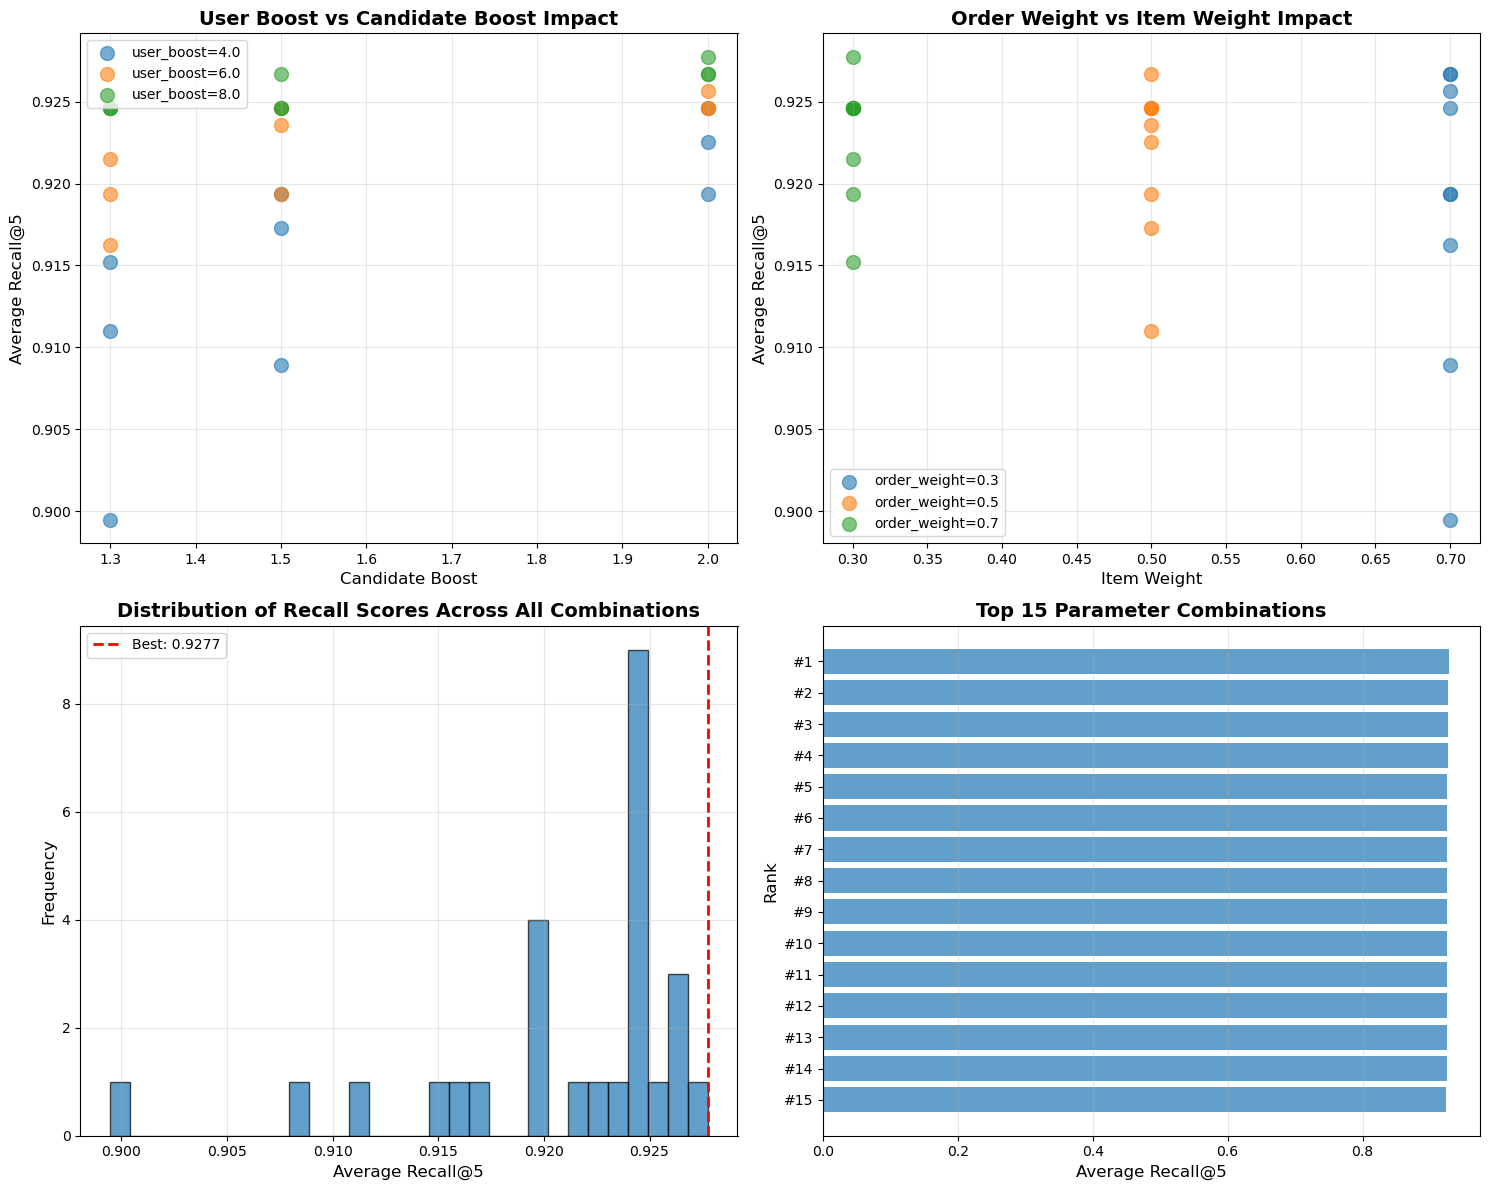


📊 Detailed Top 15 Results:
 user_boost  order_weight  item_weight  candidate_boost  avg_recall  median_recall  std_recall  time_seconds
        8.0           0.7          0.3              2.0    0.927749            1.0    0.171274     10.423381
        8.0           0.3          0.7              2.0    0.926702            1.0    0.171440     10.937599
        8.0           0.3          0.7              1.5    0.926702            1.0    0.171440     10.585550
        8.0           0.5          0.5              2.0    0.926702            1.0    0.171440     11.215822
        6.0           0.3          0.7              2.0    0.925654            1.0    0.172816     10.630869
        6.0           0.5          0.5              2.0    0.924607            1.0    0.171753     10.888342
        6.0           0.7          0.3              2.0    0.924607            1.0    0.171753     11.084100
        6.0           0.7          0.3              1.5    0.924607            1.0    0.171753     1

In [163]:
# Visualize results
import matplotlib.pyplot as plt

# Get best parameters
best_params = experiment_df.iloc[0]

print("🏆 BEST PARAMETERS FOUND:")
print("="*80)
print(f"  user_boost:      {best_params['user_boost']}")
print(f"  order_weight:    {best_params['order_weight']}")
print(f"  item_weight:     {best_params['item_weight']}")
print(f"  candidate_boost: {best_params['candidate_boost']}")
print(f"\n  Average Recall@5: {best_params['avg_recall']:.4f}")
print(f"  Median Recall@5:  {best_params['median_recall']:.4f}")
print(f"  Std Dev:          {best_params['std_recall']:.4f}")
print("="*80)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. User Boost vs Recall
ax1 = axes[0, 0]
for ub in param_grid['user_boost']:
    subset = experiment_df[experiment_df['user_boost'] == ub]
    ax1.scatter(subset['candidate_boost'], subset['avg_recall'], 
                label=f'user_boost={ub}', alpha=0.6, s=100)
ax1.set_xlabel('Candidate Boost', fontsize=12)
ax1.set_ylabel('Average Recall@5', fontsize=12)
ax1.set_title('User Boost vs Candidate Boost Impact', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Order Weight vs Recall
ax2 = axes[0, 1]
for ow in param_grid['order_weight']:
    subset = experiment_df[experiment_df['order_weight'] == ow]
    ax2.scatter(subset['item_weight'], subset['avg_recall'], 
                label=f'order_weight={ow}', alpha=0.6, s=100)
ax2.set_xlabel('Item Weight', fontsize=12)
ax2.set_ylabel('Average Recall@5', fontsize=12)
ax2.set_title('Order Weight vs Item Weight Impact', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Distribution of Recall scores
ax3 = axes[1, 0]
ax3.hist(experiment_df['avg_recall'], bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(best_params['avg_recall'], color='red', linestyle='--', linewidth=2, 
            label=f'Best: {best_params["avg_recall"]:.4f}')
ax3.set_xlabel('Average Recall@5', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Recall Scores Across All Combinations', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Top 15 combinations
ax4 = axes[1, 1]
top_15 = experiment_df.head(15)
x_pos = np.arange(len(top_15))
ax4.barh(x_pos, top_15['avg_recall'], alpha=0.7)
ax4.set_yticks(x_pos)
ax4.set_yticklabels([f"#{i+1}" for i in range(len(top_15))], fontsize=10)
ax4.set_xlabel('Average Recall@5', fontsize=12)
ax4.set_ylabel('Rank', fontsize=12)
ax4.set_title('Top 15 Parameter Combinations', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Show full top 15 results
print("\n📊 Detailed Top 15 Results:")
print(experiment_df.head(15).to_string(index=False))

### Validate Best Parameters on Full Test Set

Now that we found the best parameters on a sample, let's validate on the full test set.

In [164]:
# Validate best parameters on FULL test set
print("Validating best parameters on full test set...")
print("="*80)

best_params = experiment_df.iloc[0]
validation_start = time.time()

# Evaluate on ALL test members with best parameters
full_recall_scores = []

for member, info in test_members_info.items():
    context_items = info['context_items']
    validation_items = info['validation_items']
    
    # Get predictions with BEST parameters
    predictions = predict_top_k_items(
        member, 
        context_items, 
        k=5,
        user_boost=best_params['user_boost'],
        order_weight=best_params['order_weight'],
        item_weight=best_params['item_weight'],
        candidate_boost=best_params['candidate_boost']
    )
    
    # Calculate Recall@5
    recall = calculate_recall_at_k(predictions, validation_items, k=5)
    full_recall_scores.append(recall)

validation_time = time.time() - validation_start

print("="*80)
print(f"\n✅ Full Validation Complete! Time: {validation_time:.1f}s")
print(f"\n🏆 FINAL RESULTS WITH BEST PARAMETERS:")
print(f"  user_boost:      {best_params['user_boost']}")
print(f"  order_weight:    {best_params['order_weight']}")
print(f"  item_weight:     {best_params['item_weight']}")
print(f"  candidate_boost: {best_params['candidate_boost']}")
print(f"\n📊 Performance on Full Test Set ({len(test_members_info)} members):")
print(f"  Average Recall@5: {np.mean(full_recall_scores):.4f}")
print(f"  Median Recall@5:  {np.median(full_recall_scores):.4f}")
print(f"  Std Dev:          {np.std(full_recall_scores):.4f}")
print(f"\n📊 Performance on Sample ({sample_size} members - grid search):")
print(f"  Average Recall@5: {best_params['avg_recall']:.4f}")
print(f"  Median Recall@5:  {best_params['median_recall']:.4f}")

Validating best parameters on full test set...

✅ Full Validation Complete! Time: 38.3s

🏆 FINAL RESULTS WITH BEST PARAMETERS:
  user_boost:      8.0
  order_weight:    0.7
  item_weight:     0.30000000000000004
  candidate_boost: 2.0

📊 Performance on Full Test Set (638 members):
  Average Recall@5: 0.8966
  Median Recall@5:  1.0000
  Std Dev:          0.2021

📊 Performance on Sample (191 members - grid search):
  Average Recall@5: 0.9277
  Median Recall@5:  1.0000


In [165]:
# Save optimization results to CSV for future reference
optimization_results_file = "files/parameter_optimization_results.csv"
experiment_df.to_csv(optimization_results_file, index=False)

print(f"✅ Optimization results saved to: {optimization_results_file}")
print(f"\nSummary Statistics:")
print(f"  Best Recall@5:    {experiment_df['avg_recall'].max():.4f}")
print(f"  Worst Recall@5:   {experiment_df['avg_recall'].min():.4f}")
print(f"  Average Recall@5: {experiment_df['avg_recall'].mean():.4f}")
print(f"  Improvement:      {(experiment_df['avg_recall'].max() - experiment_df['avg_recall'].min()):.4f}")
print(f"  Improvement %:    {((experiment_df['avg_recall'].max() - experiment_df['avg_recall'].min()) / experiment_df['avg_recall'].min() * 100):.2f}%")

✅ Optimization results saved to: files/parameter_optimization_results.csv

Summary Statistics:
  Best Recall@5:    0.9277
  Worst Recall@5:   0.8995
  Average Recall@5: 0.9210
  Improvement:      0.0283
  Improvement %:    3.14%


## Generate Submission File for Last Orders

In [170]:
# Generate predictions for all members in last_orders_subset
submission_rows = []
row_id = 1

print("Generating predictions for submission...")
print("="*80)

# Get unique members from last_orders_subset
unique_members = last_orders_data['Member'].unique()

for i, member in enumerate(unique_members):
    # Get the member's current basket from last_orders_subset
    member_basket = last_orders_data[last_orders_data['Member'] == member]['SKU'].tolist()
    
    # Get order ID for this member
    order_id = last_orders_data[last_orders_data['Member'] == member]['Order'].iloc[0]
    
    # Predict top 5 items
    predictions = predict_top_k_items(member, member_basket, k=5, user_boost=8.0, order_weight=0.7, item_weight=0.3, candidate_boost=2)
    
    # Add to submission rows
    for sku in predictions:
        submission_rows.append({
            'ID': row_id,
            'Order': order_id,
            'SKU': sku,
            'Member': member
        })
        row_id += 1
    
    # Print progress
    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{len(unique_members)} members...")

print("="*80)
print(f"✅ Generated {len(submission_rows)} predictions for {len(unique_members)} members")

# Create submission DataFrame
submission_df = pd.DataFrame(submission_rows)

print(f"\nSubmission shape: {submission_df.shape}")
print(f"Expected: {len(unique_members) * 5} rows (5 predictions per member)")
print(f"\nFirst 10 rows:")
print(submission_df.head(10))

Generating predictions for submission...
Processed 100/638 members...
Processed 100/638 members...
Processed 200/638 members...
Processed 200/638 members...
Processed 300/638 members...
Processed 300/638 members...
Processed 400/638 members...
Processed 400/638 members...
Processed 500/638 members...
Processed 500/638 members...
Processed 600/638 members...
Processed 600/638 members...
✅ Generated 3190 predictions for 638 members

Submission shape: (3190, 4)
Expected: 3190 rows (5 predictions per member)

First 10 rows:
   ID    Order       SKU   Member
0   1  7409204  15668465  SWLCNOE
1   2  7409204  15668460  SWLCNOE
2   3  7409204  15668594  SWLCNOE
3   4  7409204  15668494  SWLCNOE
4   5  7409204  15669819  SWLCNOE
5   6  8076206  15669869  SWOEZES
6   7  8076206  15669878  SWOEZES
7   8  8076206   7587667  SWOEZES
8   9  8076206  15669866  SWOEZES
9  10  8076206  15669881  SWOEZES
✅ Generated 3190 predictions for 638 members

Submission shape: (3190, 4)
Expected: 3190 rows (5 pre

In [171]:
# Save to CSV file
output_file = "files/submission_hybrid.csv"
submission_df.to_csv(output_file, index=False)

print(f"✅ Submission file saved to: {output_file}")
print(f"\nFile contains:")
print(f"  - {len(submission_df)} total rows")
print(f"  - {submission_df['Member'].nunique()} unique members")
print(f"  - {submission_df['Order'].nunique()} unique orders")
print(f"  - Format: ID, Order, SKU, Member")

# Verify the format matches submission_pagerank.csv
print(f"\nColumn order: {list(submission_df.columns)}")
print(f"\nSample rows:")
submission_df.tail(10)

✅ Submission file saved to: files/submission_hybrid.csv

File contains:
  - 3190 total rows
  - 638 unique members
  - 638 unique orders
  - Format: ID, Order, SKU, Member

Column order: ['ID', 'Order', 'SKU', 'Member']

Sample rows:


,ID,Order,SKU,Member
3180,3181,8213552,15669988,SWRHRHL
3181,3182,8213552,15669875,SWRHRHL
3182,3183,8213552,15669772,SWRHRHL
3183,3184,8213552,15669869,SWRHRHL
3184,3185,8213552,15669864,SWRHRHL
3185,3186,7682167,15669789,SWOSHSO
3186,3187,7682167,15669856,SWOSHSO
3187,3188,7682167,15670107,SWOSHSO
3188,3189,7682167,15669859,SWOSHSO
3189,3190,7682167,15669815,SWOSHSO
